<a href="https://colab.research.google.com/github/HafizRizqi/MachineLearning_2026/blob/main/JS06/JS06_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🌃Lab 5
Klasifikasi Citra Siang dan Malam

Langkah 0 - Import Library

In [1]:
	# Import Required Libraries
	from pathlib import Path
	import matplotlib.image as mpimg
	import matplotlib.pyplot as plt
	import cv2
	import random
	import numpy as np
	import pandas as pd

Lakukan ekstraksi data gambar, kemudian definisikan lokasi gambar. Pada contoh ini, folder gambar berlokasi sama dengan lokasi file python.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
	# Image directories
	train_dir = "drive/MyDrive/images/training/"
	test_dir = "drive/MyDrive/images/test/"

Langkah 1 - Load Data dan Visualisasikan

In [12]:
	def load_dataset(img_dir):
	    p = Path(img_dir)
	    dirs = p.glob('*')

	    img_list = []

	    for dir in dirs:
	        label = str(dir).split('/')[-1]
	        for file in dir.glob('*.jpg'):
	            img = mpimg.imread(file)

	            if not img is None:
	                img_list.append((img, label))

	    return img_list

Load gambar training

In [13]:
	# Load training data
	train_img = load_dataset(train_dir)

Lakukan pengecekan pada salah satu data pada list. List harus berisi tuple dengan dua data, yaitu data gambar dan label dari gambar.

In [14]:
	# Check the first data
	# It should be a tuple consist of arrays of image and image labels
	train_img[0]

(array([[[140, 183, 228],
         [143, 186, 231],
         [143, 186, 231],
         ...,
         [136, 179, 224],
         [137, 180, 225],
         [137, 180, 225]],
 
        [[146, 189, 234],
         [148, 191, 236],
         [148, 191, 236],
         ...,
         [142, 185, 230],
         [142, 185, 230],
         [142, 185, 230]],
 
        [[143, 186, 231],
         [146, 189, 234],
         [145, 188, 233],
         ...,
         [139, 182, 227],
         [140, 183, 228],
         [140, 183, 228]],
 
        ...,
 
        [[130, 123, 105],
         [105,  98,  80],
         [103,  98,  79],
         ...,
         [ 93,  91,  94],
         [ 93,  91,  94],
         [ 92,  90,  93]],
 
        [[130, 123, 105],
         [ 95,  88,  70],
         [ 96,  89,  73],
         ...,
         [ 94,  94,  96],
         [ 94,  94,  96],
         [ 94,  94,  96]],
 
        [[137, 130, 112],
         [ 99,  92,  74],
         [ 91,  84,  68],
         ...,
         [ 94,  94,  96],
  

Cek ukuran gambar secara acak

In [15]:
	# Random size checking
	pick_random = np.random.randint(0, len(train_img))

	# Check img size
	print(f'Image {pick_random}')
	print(train_img[pick_random][0].shape)

Image 211
(458, 800, 3)


Tampilkan gambar untuk inspeksi secara visual. Buatlah fungsi untuk membantu memvisualkan gambar

In [21]:
	# Function to Visualize
	def random_img_viz(img_list):
	    rand_num = np.random.randint(0, len(img_list))

	    img = img_list[rand_num][0]
	    label = img_list[rand_num][1]
	    label_str = 'day' if label == 1 else 'night'

	    plt.imshow(img)
	    print(f'Shape\t: {img.shape}')
	    print(f'Label\t: {label}')

Lakukan visualisasi gambar secara acak

Shape	: (555, 800, 3)
Label	: night


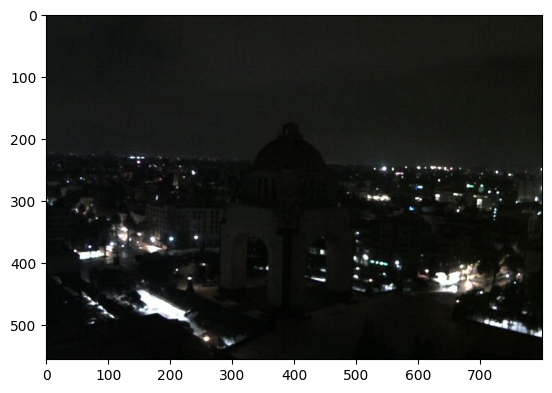

In [38]:
random_img_viz(train_img)

Langkah 3 - Pra Pengolahan Data

Pada tahap ini, saya akan melakukan dua proses utama, yaitu standardisasi ukuran gambar, dan encoding label gambar.

menstandarkan ukuran gambar

In [39]:
	def standarized_input(image):
	    # resize to w: 1100, h:600
	    std_img = cv2.resize(image, (1100,600))

	    return std_img

fungsi untuk kebutuhan encoding label.

In [40]:
	def label_encoder(label):
	    # Encode the label
	    # day as 1; night as 0
	    num_val = 0

	    if(label == 'day'):
	        num_val = 1

	    return num_val

fungsi untuk melakukan kedua hal tersebut secara sekaligus untuk semua gambar dalam list.

In [41]:
	def preprocess(img_list):
	    std_img_list = []

	    for item in img_list:
	        image = item[0]
	        label = item[1]

	        # Standarized the image
	        std_img = standarized_input(image)

	        # Create the label
	        img_label = label_encoder(label)

	        std_img_list.append((std_img, img_label))

	    return std_img_list

Lakukan pra pengolahan data pada data training.

In [42]:
train_std_img_list = preprocess(train_img)

Lakukan pengecekan ukuran gambar secara acak.

In [43]:
	# Random size checking
	pick_random = np.random.randint(0, len(train_std_img_list))

	# Check img size
	print(f'Image {pick_random}')
	print(train_std_img_list[pick_random][0].shape)

Image 158
(600, 1100, 3)


Langkah 4 - Ekstraksi Fitur

fungsi berikut untuk mendapatkan nilai rata-rata tingkat kecerahan.

In [44]:
	# Get feature based on average brightness using HSV colorspace
	def avg_brightness(image):
	    # Convert image to HSV
	    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

	    # Calculate the avg of brightness
	    sum_brightness = np.sum(img_hsv[:,:,2]) # take the 3rb value which is the V channel
	    area = image.shape[0] * image.shape[1]
	    avg = sum_brightness / area

	    return avg

 pengecekan pada gambar secara acak. INGAT! Gunakan gambar yang telah melalui proses pra pengolahan data!

Image 235
Avg Brighness: 77.4569


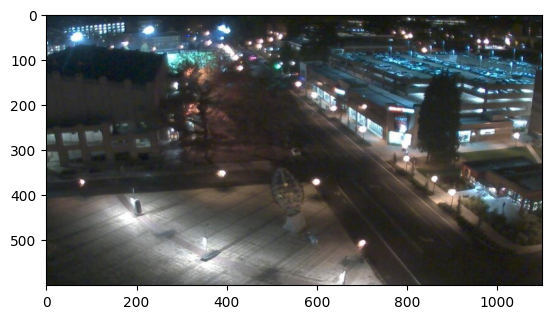

In [51]:
	# Check on random image
	rand_img = np.random.randint(0, len(train_std_img_list))

	feature_img = train_std_img_list[rand_img][0]

	avg_img = avg_brightness(feature_img)

	print(f'Image {rand_img}')
	print(f'Avg Brighness: {avg_img:.4f}')
	plt.imshow(feature_img)

Langkah 5 - Klasifikasi dengan Metode Threshold

melakukan proses klasifikasi sederhana dengan menggunakan nilai ambang batas (threshold) dari nilai rata-rata kecerahan yang kita tentukan sendiri.

In [52]:
	def predict_label(img, threshold):
	    # Computer average brightness
	    avg = avg_brightness(img)
	    pred = 0

	    # Predict the label based on user defined threshold
	    if avg > threshold:
	        pred = 1

	    return pred

pengecekan prediksi secara acak pada data training

Image 164
Actual label: 0
Predicted label: 0


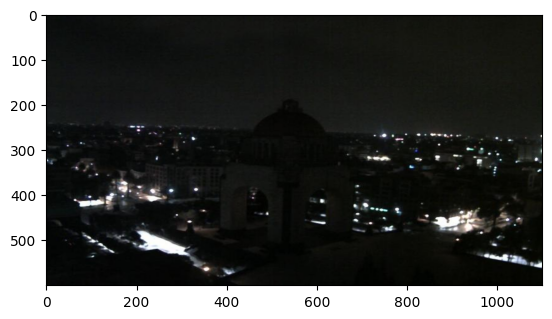

In [54]:
	# Test the classifier on train data
	rand_img = np.random.randint(0, len(train_std_img_list))

	pred = predict_label(train_std_img_list[rand_img][0], threshold=120)

	# Evaluate
	print(f'Image {rand_img}')
	print(f'Actual label: {train_std_img_list[rand_img][1]}')
	print(f'Predicted label: {pred}')
	plt.imshow(train_std_img_list[rand_img][0])

Langkah 6 - Evaluasi Manual

membuat fungsi evaluasi model sederhana, yaitu dengan membandingkan label yang diprediksi benar dengan seluruh data. Ingat kembali konsep confussion matrix.

In [55]:
	def evaluate(img_list, threshold):
	    miss_labels = []

	    for file in img_list:
	        # Get the ground truth / correct label
	        img = file[0]
	        label = file[1]

	        # Get prediction
	        pred_label = predict_label(img, threshold)

	        # Compare ground truth and pred
	        if pred_label != label:
	            miss_labels.append((img, pred_label, label))

	    total_img = len(img_list)
	    corr_pred = total_img - len(miss_labels)
	    accuracy = corr_pred / total_img

	    print(f'Accuracy: {accuracy:.4f}')

 evaluasi pada data training dengan nilai ambang batas 120.

In [56]:
	# Evaluate on train data
	evaluate(train_std_img_list, threshold=120)

Accuracy: 0.8417


melakukan evaluasi pada data testing. Namun sebelumnya, data testing harus diperlakukan sama dengan data training dalam konteks pra progolahan data dan ekstraksi fitur.

In [57]:
	# Evaluate on test data

	# Load test data
	test_img = load_dataset(test_dir)

	# Preprocess
	test_std_img_list = preprocess(test_img)

	# Predict
	evaluate(test_std_img_list, threshold=120)

Accuracy: 0.8688


# Klasifikasi dengan SVM

Sebelumnya, saya hanya menggunakan threshold sebagai acuan. Cara ini mungkin tidak efektif dikarenakan saya harus menentukan threshold dengan tepat. Oleh karena itu, selanjutnya saya akan mencoba menggunakan model SVM untuk proses klasifikasi. Seluruh langkah yang digunakan serupa, saya hanya mengubah mulai langkah ke-4.

Langkah 4 Alternatif - Membuat Feature Vectors.

Perbedaan mendasar dari langkah 4 sebelumnya adalah, kita akan melakukan tabulasi semua nilai rata-rata kecerahan pada data, dan menyimpannya dalam bentuk tabel. Dalam konteks ini, kita akan membuat tabel dengan kolom fitur dan label.

In [58]:
	# Create function to extract feature for every images and stored in tabular data
	# Stored in Pandas dataframe
	def extract_avg_bright_feature(img_list):
	    avg_list = []
	    labels = []

	    for img in img_list:
	        img_avg = avg_brightness(img[0]) # Get the avg brightness from image
	        img_label = img[1] # Get the image label

	        avg_list.append(img_avg)
	        labels.append(img_label)

	    # Stack data in columcular way
	    data = np.column_stack((avg_list, labels))
	    # Create a Pandas dataframe
	    df = pd.DataFrame(data, columns=['AVG_BRIGHT', 'LABELS'])

	    return df

Cek hasilnya pada data training,

In [59]:
	# Extract feature on train data
	train_avg_img = extract_avg_bright_feature(train_std_img_list)
	print(f'Shape: {train_avg_img.shape}')
	train_avg_img.head()

Shape: (240, 2)


,AVG_BRIGHT,LABELS
0,196.826403,1.0
1,191.274988,1.0
2,197.451662,1.0
3,195.107926,1.0
4,105.506424,1.0


Lakukan langkah yang serupa pada data testing

In [60]:
	# Do the same thing on test data
	test_avg_img = extract_avg_bright_feature(test_std_img_list)
	print(f'Shape: {test_avg_img.shape}')
	test_avg_img.head()

Shape: (160, 2)


,AVG_BRIGHT,LABELS
0,56.674038,0.0
1,46.693686,0.0
2,51.373026,0.0
3,48.083733,0.0
4,47.079873,0.0


Langkah 5 - Buat Model SVM

kita akan membuat model SVM dengan kernel RBF (default) dengan memanfaatkan libary scikit-learn

In [61]:
	# import requied library
	from sklearn.svm import SVC

	# Split data and label
	X_train = train_avg_img.iloc[:,0].values.reshape(-1,1)
	y_train = train_avg_img.iloc[:,1]
	X_test = test_avg_img.iloc[:,0].values.reshape(-1,1)
	y_test = test_avg_img.iloc[:,1]

	model = SVC()
	model.fit(X_train, y_train)

SVC()

Langkah 6 - Evaluasi

melakukan evaluasi pada data training dan testing dengan bantuan library scikit-learn.

In [62]:
	from sklearn.metrics import accuracy_score

	# Make a prediction on train data
	y_train_pred = model.predict(X_train)

	# Get the accuracy on train data
	acc_train = accuracy_score(y_train, y_train_pred)

	# Make a prediction on test data
	y_test_pred = model.predict(X_test)

	# Get the accuracy on test data
	acc_test = accuracy_score(y_test, y_test_pred)

	# Print Eval Result
	print(f'Accuracy on train: {acc_train}')
	print(f'Accuracy on test: {acc_test}')

Accuracy on train: 0.8583333333333333
Accuracy on test: 0.9
